<a href="https://colab.research.google.com/github/vecodesh/class-exercise/blob/main/Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

data = load_iris()
X = data.data
y = data.target



In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [3]:
clf = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)
clf.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [4]:
y_pred = clf.predict(X_test)

In [5]:
pre_pruned_clf = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=3,
    min_samples_leaf=5,
    random_state=42
)
pre_pruned_clf.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=5,
                       random_state=42)

In [6]:
print(
    "Pre-Pruned Accuracy:",
    accuracy_score(y_test, pre_pruned_clf.predict(X_test))
)

Pre-Pruned Accuracy: 1.0


In [7]:
path = clf.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

pruned_models = []
accuracies = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(
        ccp_alpha=alpha,
        random_state=42
    )
    model.fit(X_train, y_train)
    pruned_models.append(model)
    accuracies.append(
        accuracy_score(y_test, model.predict(X_test))
    )

best_alpha = ccp_alphas[accuracies.index(max(accuracies))]
print("Best ccp_alpha:", best_alpha)


Best ccp_alpha: 0.0


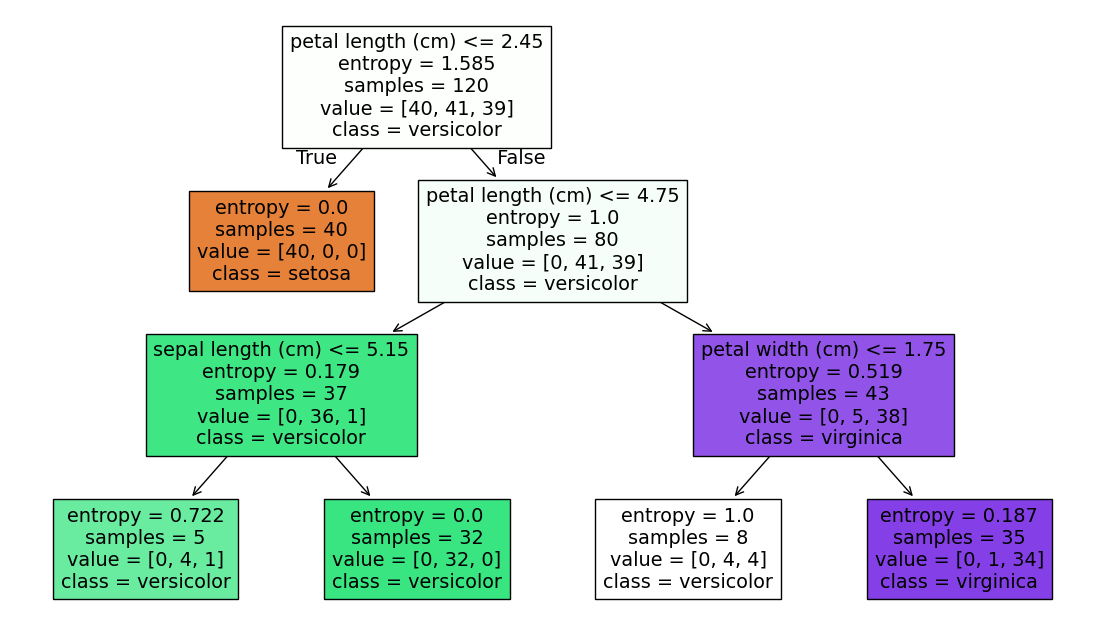

sepal length (cm) : 0.0176
sepal width (cm) : 0.0
petal length (cm) : 0.9374
petal width (cm) : 0.045


In [8]:
plt.figure(figsize=(14, 8))
plot_tree(
    pre_pruned_clf,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True
)
plt.show()
for name, importance in zip(
    data.feature_names,
    pre_pruned_clf.feature_importances_
):
    print(name, ":", round(importance, 4))


In [9]:
from sklearn.datasets import load_diabetes
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = load_diabetes()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
reg = DecisionTreeRegressor(random_state=42)
reg.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
y_pred = reg.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

Mean Squared Error: 4976.797752808989


In [12]:
pre_pruned_reg = DecisionTreeRegressor(
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
pre_pruned_reg.fit(X_train, y_train)

print(
    "Pre-Pruned MSE:",
    mean_squared_error(y_test, pre_pruned_reg.predict(X_test))
)


Pre-Pruned MSE: 3150.6051154756356


In [13]:
path = reg.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

pruned_models = []
mses = []

for alpha in ccp_alphas:
    model = DecisionTreeRegressor(
        ccp_alpha=alpha,
        random_state=42
    )
    model.fit(X_train, y_train)
    pruned_models.append(model)
    mses.append(
        mean_squared_error(y_test, model.predict(X_test))
    )

best_alpha = ccp_alphas[mses.index(min(mses))]
print("Best ccp_alpha:", best_alpha)


Best ccp_alpha: 80.57696804297389
